# Detecting Severity of Damaged Vehicle Using Accident Images

<img src="https://github.com/databricks-demos/dbdemos-resources/blob/main/images/fsi/smart-claims/fsi-claims-flow-4.png?raw=true" style="float: right" width="1000px">

At this point, our data ingestion pipeline has brought in the relevant datasets including policy, claim, and telematics data. 

To improve our claim processing, we want to be able to automatically detect the incident severity and use this information in our process rules.

### Leveraging Databricks Deep Learning AI capabilities on unstructured images

When our customers fill claims, they can add images of the incident using their smartphone. These images are captured and saved as part of the claims.

In this notebook, we will be using a training dataset containing images with the corresponding incident severity as label (good condition, minor damages or major damages). 

We'll leverage the Data Intelligence Platform capabilities to fine-tune a state of the art model (`ResNet-50`) to classify our claims images. 

The model is an AI asset that will be saved in a catalog under Unity Catalog for <b> centralized governance and control.</b>


<!-- Collect usage data (view). Remove it to disable collection or disable tracker during installation. View README for more details.  -->
<img width="1px" src="https://ppxrzfxige.execute-api.us-west-2.amazonaws.com/v1/analytics?category=lakehouse&org_id=2162748966026566&notebook=%2F02-Data-Science-ML%2F02.1-Model-Training&demo_name=lakehouse-fsi-smart-claims&event=VIEW&path=%2F_dbdemos%2Flakehouse%2Flakehouse-fsi-smart-claims%2F02-Data-Science-ML%2F02.1-Model-Training&version=1">

In [0]:
%pip install databricks-sdk==0.39.0 datasets==2.20.0 transformers==4.49.0 tf-keras==2.17.0 accelerate==1.4.0 mlflow==2.20.2 torchvision==0.20.1 deepspeed==0.14.4
dbutils.library.restartPython()

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/44.0 kB ? eta -:--:--
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/1.3 MB ? eta -:--:--
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸ 1.3/1.3 MB 45.0 MB/s eta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 31.8 MB/s eta 0:00:00
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/623.0 kB ? eta -:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 623.0/623.0 kB 73.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/547.8 kB ? eta -:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 547.8/547.8 kB 66.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/10.0 MB ? eta -:--:--
   ━━━━━━━━━━━━━━━━━━━━━╸━━━━━━━━━━━━━━━━━━ 5.4/10.0 MB 160.5 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸ 10.0/10.0 MB 175.3 M

In [0]:
%run ../_resources/00-setup

run done
USE CATALOG `main__build`
using catalog.database `main__build`.`dbdemos_fsi_smart_claims`


data already existing.


## Loading and preparing our dataset from Unity Catalog Volume

Let's start by reviewing our training dataset. The raw images have been stored and secured using Databricks Volumes, under your Unity Catalog `catalog`.`schema`.

Let's ingest our raw images and save them as a Delta table within Unity Catalog. We'll apply some transformation to prepare our training dataset. 

As our Deep learning model ResNet-50 was trained on 224x224 images, we will resize each picture, adding black background if required. This process will parallelize using spark User Defined Functions (UDF), persisting the binary data back into a Delta Lake table.

In [0]:
from pyspark.sql.functions import regexp_extract
training_df = spark.read.format('binaryFile').load(f"/Volumes/{catalog}/{db}/{volume_name}/Images")
#Extract label from image name
training_df = training_df.withColumn("label", regexp_extract("path", r"/(\d+)-([a-zA-Z]+)\.png$", 2))
display(training_df.limit(1))

path,modificationTime,length,content,label
dbfs:/Volumes/main/dbdemos_fsi_smart_claims/volume_claims/Images/29-minor.png,2025-10-23T22:20:01Z,2053150,"List(iVBORw0KGgoAAAANSUhEUgAABAAAAAQACAIAAADwf7zUAAEAAElEQVR4nDz919MsWXbliW1xznER8tP35hWpq7JQQEF1N4bNHo6NcUizGRsayXnln8fX4QtJM7YZp8lWAApANdBAidSZN/PKT4Z2cc4WfIhqvoRZvISbh7ub770= (truncated), ...)",minor


In [0]:
import io
from pyspark.sql.functions import pandas_udf, col
IMAGE_RESIZE = 224

#Resize UDF function
@pandas_udf("binary")
def resize_image_udf(content_series):
  def resize_image(content):
    from PIL import Image
    """resize image and serialize back as jpeg"""
    #Load the PIL image
    image = Image.open(io.BytesIO(content))
    width, height = image.size   # Get dimensions
    new_size = min(width, height)
    # Crop the center of the image
    image = image.crop(((width - new_size)/2, (height - new_size)/2, (width + new_size)/2, (height + new_size)/2))
    #Resize to the new resolution
    image = image.resize((IMAGE_RESIZE, IMAGE_RESIZE), Image.NEAREST)
    #Save back as jpeg
    output = io.BytesIO()
    image.save(output, format='JPEG')
    return output.getvalue()
  return content_series.apply(resize_image)


# add the metadata to enable the image preview
image_meta = {"spark.contentAnnotation" : '{"mimeType": "image/jpeg"}'}

(training_df
      .withColumn("content", resize_image_udf(col("content")).alias("content", metadata=image_meta))
      .write.mode('overwrite').saveAsTable("training_dataset"))

In [0]:
display(spark.table("training_dataset").limit(10))

path modificationTime length content label dbfs:/Volumes/main/dbdemos_fsi_smart_claims/volume_claims/Images/0-ok.png 2025-10-23T22:20:00Z 1826771 List(/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBwcJCQgKDBQNDAsLDBkSEw8UHRofHh0aHBwgJC4nICIsIxwcKDcpLDAxNDQ0Hyc5PTgyPC4zNDL/2wBDAQkJCQwLDBgNDRgyIRwhMjIyMjIyMjIyMjIyMjIyMjIyMjI= (truncated), ...) ok dbfs:/Volumes/main/dbdemos_fsi_smart_claims/volume_claims/Images/1-minor.png 2025-10-23T22:20:00Z 1596986 List(/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBwcJCQgKDBQNDAsLDBkSEw8UHRofHh0aHBwgJC4nICIsIxwcKDcpLDAxNDQ0Hyc5PTgyPC4zNDL/2wBDAQkJCQwLDBgNDRgyIRwhMjIyMjIyMjIyMjIyMjIyMjIyMjI= (truncated), ...) minor dbfs:/Volumes/main/dbdemos_fsi_smart_claims/volume_claims/Images/10-ok.png 2025-10-23T22:20:00Z 1587948 List(/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBwcJCQgKDBQNDAsLDBkSEw8UHRofHh0aHBwgJC4nICIsIxwcKDcpLDAxNDQ0Hyc5PTgyPC4zNDL/2wBDAQkJCQwLDBgNDRgyIRwhMjIyMjIyMjIyMjIyMjIyMjIyMjI= (truncated), ...) ok dbfs:/Volumes/main/dbdemos_fsi_smart_claims/volume_claims/Images/11-ok.png 2025-10-23T22:20:00Z 1550221 List(/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBwcJCQgKDBQNDAsLDBkSEw8UHRofHh0aHBwgJC4nICIsIxwcKDcpLDAxNDQ0Hyc5PTgyPC4zNDL/2wBDAQkJCQwLDBgNDRgyIRwhMjIyMjIyMjIyMjIyMjIyMjIyMjI= (truncated), ...) ok dbfs:/Volumes/main/dbdemos_fsi_smart_claims/volume_claims/Images/12-ok.png 2025-10-23T22:20:00Z 1400100 List(/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBwcJCQgKDBQNDAsLDBkSEw8UHRofHh0aHBwgJC4nICIsIxwcKDcpLDAxNDQ0Hyc5PTgyPC4zNDL/2wBDAQkJCQwLDBgNDRgyIRwhMjIyMjIyMjIyMjIyMjIyMjIyMjI= (truncated), ...) ok dbfs:/Volumes/main/dbdemos_fsi_smart_claims/volume_claims/Images/13-ok.png 2025-10-23T22:20:00Z 1380695 List(/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBwcJCQgKDBQNDAsLDBkSEw8UHRofHh0aHBwgJC4nICIsIxwcKDcpLDAxNDQ0Hyc5PTgyPC4zNDL/2wBDAQkJCQwLDBgNDRgyIRwhMjIyMjIyMjIyMjIyMjIyMjIyMjI= (truncated), iVBORw0KGgoAAAANSUhEUgAAAGQAAABkCAIAAAD/gAIDAAA2kklEQVR4Xu18B1QVSfb+G8eMopgwgDlnHcVAkIzknHPOIklAwISogCISzQlRgoqIiFlRFBNJcnwBMIzO7O6knbS////rvtrz5qmjM7PhnD17z3eK6urq6qqv7r1Vt/s1PMF/XjoJfH4HpUIhnyv8Nf5pIhQTyXNvhM/nS5TwJI7/E/KaC3BEfP2PrN+QX+ggtWpubnyLpv86sujGfFaohPLiJZyIdfQ1F52d7UgfP37o7+/75EkNHRKDBLQnEBvDB0creNeAOfngtW8LT/zgY27/TsElIpFIokTA9pVrjWtcvH1koUqEri5he3trSkqypaV5YeEZtEcc0VmWrF81QiI+E8I3Lf8GR39GeOIHXA/EC39bxOtLXM5luPFQhst3vpZ2Qk1NVV7eqaSkhNjY6ISE7SUlxW8U6rUX49p/W6g18WbpLsLfM5YPCk/8gLu3eOEHBTqFS9ra2tqhGK2tzc3NTU1NLS0traygsI0VLgNBOVLUfPKkFhxVVT2G9ZWX387Jyfb0dHd2doyMXJebe/LWrRt37965d6/84cP7jx49qK6urqurQ8toqqMDPDJq29XV1c1KT08PZVDCDYEo+2cJT7Lgt+SXRYrtDLvYC/nVtVWXrpTW1tXUN9Y3NTc2Njc0NNU3NDU8qX+CfFNLY139k1tlN88UniksOpuXn7v/4L6sfZlZezMzstJT0/fs3pOckrob2JO6Oz0zDZk1QQEoBPakpaRlpKLmvgN79+3POnjowP4D+3D5wcMHDhzcf+jwweyc47l5p06fLSgsKsQtcMfm1qb2zrZOQQfQ0dmOXpWUlrS0NXfCnEWMXxSxIjmyjxOeZMFvya9WdDAFTcoryN0ct+nQkYMnc3Ny808dOXYYg0zalYjCNWsDvX29fPy8/QJ8AV9/H0LAGn+Cf6AfnUIGQAnlLa0tUA15lAQGBQQFrwkOXQuErQsFIqLWRUVHRseu37Rl48bNG4ANm2LXx0ThEIW4767dOzP3ZqAnmJuS0gully+i5Or1Kx2djNf7w0wJ/jBZcDEtLU2HDx/08HLHACLXRxAwNgzS3dMNcHFzdnR2sHe0c3CyB+wcbK1trWztbQArG0sCeEEhZcwtzZAxszBF3sLKnIA81bSxswbocrTp7OqE9l3dXXAjLx9PkAuWkYJTEAfKdiRuT07ZBeWFGh49fgTzl1+Qx7lLyZF9nPAkC94v3F4ROtXW1gKf4uLi5OnlgS6CMjcPV/SeGKExm5gZA0YmhobGBgZG+rr6q1fr6ejoahO0V2sBWjqamtoagIaWurqmGlIClSODlGrSVWhE31APraFNtIz2QbGpuQlSmgmkoBIkgkEoZnhEWMyG6PjtWxN3JqyLWHfmzBnMM3m0P0AZT/zgtx08rd/Q4o6OtsuXS728PKytLZ2cHdA/9JV40TPQBSM0fgxeTUNVVX3VKjUVFVVl5VVKgJKKIqCovHKl0ooVisuB5SuXSYDKOaAm6gO4EC2gKbSJxolc0AoqcVPcmpsYdAZaCe6g2phFeIO1IUGRURFubm4lJSWC9+xpfjXaN8KdhfAkT75fyKmDsvv370VFRaiqqhgZGeiz7KDH6DqGQaRgVBghhr1shQJAFCCjsHypOOjU0mVL3gbOIl2i8BlSqkasccAt6F50U8wHGMTccCoJNQR9IA46Dk0Ha+4ebl5eXs7OzpcvX6Z9hjgRwt9L1utd0Hv0s5NxkJ1NTQ2ZmekqKkoaGmqamupq6qvQV2IH48EgkecGDNCAxQniBi8xflIfjgtSQHGd4jIEUAOOqBpXn1jDWY4+6B2M19jUyNLKwt7e3sTEJCgoqKKigjy9OBeSA2ZFvAJP8uRviJCPxfjS5Yt29jafLV2MrmBUy94wQuDI4koWfbaQsHDxApQjXbBoPlLKzF84TxzzFsxFunjJItTELagCUu4StIOzOAWiybtBo4l3bg6IO86KiUGom46ujomZCSjT1NZMSNyBXU4nu/WRHOb7hSdZ8H7hC/mPqx4lJO2YO38OWEDn0Gl0nRsSjQQpDRvV5sybPXvurFlzZgLIgF+iDHVmzJo+bcZUlE+fOY2AQwDluBCYOXsG8qiADEA

# Fine tuning our model with Hugging Face transformers (transfer learning)

Our dataset is now ready, and properly labeled.

Let's load our Delta Table containing the images and prepare them for hugging face. 

Databricks makes it easy to convert a Table to a transformers Dataset using the `dataset` libraries.

We'll then retrain the base model from its latest checkpoint.

In [0]:
from datasets import Dataset
#Setup the training experiment
DBDemos.init_experiment_for_batch("lakehouse-fsi-smart-claims", "hf")

#Note: from_spark support coming with serverless compute - we'll use from_pandas for this simple demo having a small dataset
#dataset = Dataset.from_spark(spark.table("training_dataset"), cache_dir="/tmp/hf_cache/train").rename_column("content", "image")
dataset = Dataset.from_pandas(spark.table("training_dataset").toPandas()).rename_column("content", "image")

splits = dataset.train_test_split(test_size=0.2, seed = 42)
train_ds = splits['train']
val_ds = splits['test']

Using common experiment under /Shared/dbdemos/experiments/lakehouse-fsi-smart-claims/hf
Experiment on /Shared/dbdemos/experiments/lakehouse-fsi-smart-claims/hf was set public


In [0]:
import torch
from transformers import AutoFeatureExtractor, AutoImageProcessor

# pre-trained model from which to fine-tune
# Check the hugging face repo for more details & models: https://huggingface.co/microsoft/resnet-50
model_checkpoint = "microsoft/resnet-50"

from PIL import Image
import io
from torchvision.transforms import CenterCrop, Compose, Normalize, RandomResizedCrop, Resize, ToTensor, Lambda

#Extract the model feature (contains info on pre-process step required to transform our data, such as resizing & normalization)
#Using the model parameters makes it easy to switch to another model without any change, even if the input size is different.
model_def = AutoFeatureExtractor.from_pretrained(model_checkpoint)

#Transformations on our training dataset. we'll add some crop here
transforms = Compose([Lambda(lambda b: Image.open(io.BytesIO(b)).convert("RGB")), #byte to pil
                        ToTensor(), #convert the PIL img to a tensor
                        Normalize(mean=model_def.image_mean, std=model_def.image_std)
                        ])

# Add some random resiz & transformation to our training dataset
def preprocess(batch):
    """Apply train_transforms across a batch."""
    batch["image"] = [transforms(image) for image in batch["image"]]
    return batch
   
#Set our training / validation transformations
train_ds.set_transform(preprocess)
val_ds.set_transform(preprocess)

2025-11-03 22:13:26.504909: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-11-03 22:13:26.519930: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-11-03 22:13:26.524413: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-11-03 22:13:26.535717: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-03 22:13:28.234662: W tensorflow/compiler/tf2

preprocessor_config.json:   0%|          | 0.00/266 [00:00<?, ?B/s]

In [0]:
from transformers import AutoModelForImageClassification, TrainingArguments, Trainer

#Mapping between class label and value (huggingface use it during inference to output the proper label)
label2id, id2label = dict(), dict()
for i, label in enumerate(set(dataset['label'])):
    label2id[label] = i
    id2label[i] = label
    
#Load the base model from its checkpoint
model = AutoModelForImageClassification.from_pretrained(
    model_checkpoint, 
    label2id=label2id,
    id2label=id2label,
    num_labels=len(label2id),
    ignore_mismatched_sizes = True # provide this in case you're planning to fine-tune an already fine-tuned checkpoint
)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

Some weights of ResNetForImageClassification were not initialized from the model checkpoint at microsoft/resnet-50 and are newly initialized because the shapes did not match:
- classifier.1.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([3]) in the model instantiated
- classifier.1.weight: found shape torch.Size([1000, 2048]) in the checkpoint and torch.Size([3, 2048]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


## Fine tuning our model 

Our dataset and model is ready. We can now start the training step to fine-tune the model.

*Note that for production-grade use-case, we would typically to do some [hyperparameter](https://huggingface.co/docs/transformers/hpo_train) tuning here. We'll keep it simple for this first example and run it with fixed settings.*


In [0]:
model_name = model_checkpoint.split("/")[-1]

from transformers import TrainingArguments
args = TrainingArguments(
    f"/tmp/huggingface/pcb/{model_name}-finetuned",
    no_cuda=True, #Run on CPU for resnet to make it easier
    remove_unused_columns=False,
    evaluation_strategy = "epoch",
    save_strategy = "epoch",
    num_train_epochs=20,
    load_best_model_at_end=True
)

In [0]:
import mlflow
# This wrapper adds steps before and after the inference to simplify the model usage
# Before calling the model: apply the same transform as the training, resizing the image
# After callint the model: only keeps the main class with the probability as output
class ModelWrapper(mlflow.pyfunc.PythonModel):
    def __init__(self, pipeline):
        self.pipeline = pipeline
        # instantiate model in evaluation mode
        self.pipeline.model.eval()

    def predict(self, context, images):
        from PIL import Image
        with torch.set_grad_enabled(False):
            #Convert the byte to PIL images
            images = images['content'].apply(lambda b: Image.open(io.BytesIO(b))).to_list()
            #the pipeline returns the probability for all the class
            predictions = self.pipeline.predict(images)
            #Filter & returns only the class with the highest score [{'score': 0.999038815498352, 'label': 'normal'}, ...]
            return pd.DataFrame([max(r, key=lambda x: x['score']) for r in predictions])

/local_disk0/.ephemeral_nfs/envs/pythonEnv-b3e84733-21d3-426e-8436-9a97672e9c73/lib/python3.12/site-packages/mlflow/pyfunc/utils/data_validation.py:166: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(


In [0]:
from transformers import pipeline, DefaultDataCollator, EarlyStoppingCallback
from mlflow.models import infer_signature

mlflow.autolog(disable=True)
with mlflow.start_run(run_name="hugging_face") as run:
  mlflow.log_input(mlflow.data.from_huggingface(train_ds, "training"))
  def collate_fn(examples):
    pixel_values = torch.stack([e["image"] for e in examples])
    labels = torch.tensor([label2id[e["label"]] for e in examples], dtype=torch.float)
    labels = torch.nn.functional.one_hot(labels.long(), 3).float()
    return {"pixel_values": pixel_values, "labels": labels}

  trainer = Trainer(model, args, train_dataset=train_ds, eval_dataset=val_ds, tokenizer=model_def, data_collator=collate_fn) 

  train_results = trainer.train()
  #Build our final hugging face pipeline
  classifier = pipeline("image-classification", model=trainer.state.best_model_checkpoint, tokenizer = model_def)

  #Wrap the model to easily ingest images and output better results
  wrapped_model = ModelWrapper(classifier)
  test_df = spark.table("training_dataset").select('content').toPandas()
  predictions = wrapped_model.predict(None, test_df)
  signature = infer_signature(test_df, predictions)
    
  reqs = mlflow.transformers.get_default_pip_requirements(model)
  #log the model to MLFlow
  mlflow.pyfunc.log_model(artifact_path="model", python_model=wrapped_model, pip_requirements=reqs, signature=signature)
  mlflow.log_metrics(train_results.metrics)

[2025-11-03 22:13:33,829] [WARNING] [real_accelerator.py:162:get_accelerator] Setting accelerator to CPU. If you have GPU or other accelerator, we were unable to detect it.
[2025-11-03 22:13:33,834] [INFO] [real_accelerator.py:203:get_accelerator] Setting ds_accelerator to cpu (auto detect)


df: /root/.triton/autotune: No such file or directory
[rank0]:[W1103 22:13:35.731379225 reducer.cpp:1400] Warning: find_unused_parameters=True was specified in DDP constructor, but did not find any unused parameters in the forward pass. This flag results in an extra traversal of the autograd graph every iteration,  which can adversely affect performance. If your model indeed never has any unused parameters in the forward pass, consider turning this flag off. Note that this warning may be a false positive if your model has flow control causing later iterations to have unused parameters. (function operator())


Epoch,Training Loss,Validation Loss
1,No log,0.687577
2,No log,0.683106
3,No log,0.679607
4,No log,0.678618
5,No log,0.678371
6,No log,0.671938
7,No log,0.670023
8,No log,0.665124
9,No log,0.669794
10,No log,0.674284


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.48, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
Device set to use cpu


Uploading artifacts:   0%|          | 0/9 [00:00<?, ?it/s]

## Let's now save our model to Unity Catalog

Our model is ready, we can easily add it to Unity Catalog and ensure other users can access it.

Our Data Engineers or MLOps team will be able to load it to run the inferences.

In [0]:
from mlflow.tracking import MlflowClient

model_name = "dbdemos_claims_damage_level"

#Use Databricks Unity Catalog to save our model
mlflow.set_registry_uri('databricks-uc')
client = MlflowClient()
#Add model within our catalog
latest_model = mlflow.register_model(f'runs:/{run.info.run_id}/model', f"{catalog}.{db}.{model_name}")
# Flag it as Production ready using UC Aliases
client.set_registered_model_alias(name=f"{catalog}.{db}.{model_name}", alias="prod", version=latest_model.version)

Registered model 'main.dbdemos_fsi_smart_claims.dbdemos_claims_damage_level' already exists. Creating a new version of this model...


Uploading artifacts:   0%|          | 0/9 [00:00<?, ?it/s]

Created version '4' of model 'main.dbdemos_fsi_smart_claims.dbdemos_claims_damage_level'.


### Test by loading the model for inferencing

In [0]:
#Load back the model
predict_damage_udf = mlflow.pyfunc.spark_udf(spark, model_uri=f"models:/{catalog}.{db}.{model_name}@prod")
columns = predict_damage_udf.metadata.get_input_schema().input_names()
#Run the inferences
spark.table('training_dataset').withColumn("damage_prediction", predict_damage_udf(*columns)).write.mode('overwrite').saveAsTable('damage_predictions')
predictions = spark.table('damage_predictions')
display(predictions)

2025/11/03 22:16:02 WARNING mlflow.pyfunc: Calling `spark_udf()` with `env_manager="local"` does not recreate the same environment that was used during training, which may lead to errors or inaccurate predictions. We recommend specifying `env_manager="conda"`, which automatically recreates the environment that was used to train the model and performs inference in the recreated environment.


2025/11/03 22:16:02 INFO mlflow.models.flavor_backend_registry: Selected backend for flavor 'python_function'


path,modificationTime,length,content,label,damage_prediction
dbfs:/Volumes/main/dbdemos_fsi_smart_claims/volume_claims/Images/45-major.png,2025-10-23T22:20:02Z,1870769,"List(/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBwcJCQgKDBQNDAsLDBkSEw8UHRofHh0aHBwgJC4nICIsIxwcKDcpLDAxNDQ0Hyc5PTgyPC4zNDL/2wBDAQkJCQwLDBgNDRgyIRwhMjIyMjIyMjIyMjIyMjIyMjIyMjI= (truncated), ...)",major,"List(major, 0.48433542251586914)"
dbfs:/Volumes/main/dbdemos_fsi_smart_claims/volume_claims/Images/46-major.png,2025-10-23T22:20:02Z,1846070,"List(/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBwcJCQgKDBQNDAsLDBkSEw8UHRofHh0aHBwgJC4nICIsIxwcKDcpLDAxNDQ0Hyc5PTgyPC4zNDL/2wBDAQkJCQwLDBgNDRgyIRwhMjIyMjIyMjIyMjIyMjIyMjIyMjI= (truncated), ...)",major,"List(major, 0.48389944434165955)"
dbfs:/Volumes/main/dbdemos_fsi_smart_claims/volume_claims/Images/47-major.png,2025-10-23T22:20:02Z,1765672,"List(/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBwcJCQgKDBQNDAsLDBkSEw8UHRofHh0aHBwgJC4nICIsIxwcKDcpLDAxNDQ0Hyc5PTgyPC4zNDL/2wBDAQkJCQwLDBgNDRgyIRwhMjIyMjIyMjIyMjIyMjIyMjIyMjI= (truncated), ...)",major,"List(major, 0.4856772720813751)"
dbfs:/Volumes/main/dbdemos_fsi_smart_claims/volume_claims/Images/48-major.png,2025-10-23T22:20:02Z,1770028,"List(/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBwcJCQgKDBQNDAsLDBkSEw8UHRofHh0aHBwgJC4nICIsIxwcKDcpLDAxNDQ0Hyc5PTgyPC4zNDL/2wBDAQkJCQwLDBgNDRgyIRwhMjIyMjIyMjIyMjIyMjIyMjIyMjI= (truncated), ...)",major,"List(major, 0.48811399936676025)"
dbfs:/Volumes/main/dbdemos_fsi_smart_claims/volume_claims/Images/49-major.png,2025-10-23T22:20:02Z,2019231,"List(/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBwcJCQgKDBQNDAsLDBkSEw8UHRofHh0aHBwgJC4nICIsIxwcKDcpLDAxNDQ0Hyc5PTgyPC4zNDL/2wBDAQkJCQwLDBgNDRgyIRwhMjIyMjIyMjIyMjIyMjIyMjIyMjI= (truncated), ...)",major,"List(major, 0.48589128255844116)"
dbfs:/Volumes/main/dbdemos_fsi_smart_claims/volume_claims/Images/5-ok.png,2025-10-23T22:20:02Z,1540234,"List(/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBwcJCQgKDBQNDAsLDBkSEw8UHRofHh0aHBwgJC4nICIsIxwcKDcpLDAxNDQ0Hyc5PTgyPC4zNDL/2wBDAQkJCQwLDBgNDRgyIRwhMjIyMjIyMjIyMjIyMjIyMjIyMjI= (truncated), ...)",ok,"List(minor, 0.49995243549346924)"
dbfs:/Volumes/main/dbdemos_fsi_smart_claims/volume_claims/Images/50-ok.png,2025-10-23T22:20:02Z,1637245,"List(/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBwcJCQgKDBQNDAsLDBkSEw8UHRofHh0aHBwgJC4nICIsIxwcKDcpLDAxNDQ0Hyc5PTgyPC4zNDL/2wBDAQkJCQwLDBgNDRgyIRwhMjIyMjIyMjIyMjIyMjIyMjIyMjI= (truncated), ...)",ok,"List(major, 0.45171651244163513)"
dbfs:/Volumes/main/dbdemos_fsi_smart_claims/volume_claims/Images/51-major.png,2025-10-23T22:20:02Z,1830434,"List(/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBwcJCQgKDBQNDAsLDBkSEw8UHRofHh0aHBwgJC4nICIsIxwcKDcpLDAxNDQ0Hyc5PTgyPC4zNDL/2wBDAQkJCQwLDBgNDRgyIRwhMjIyMjIyMjIyMjIyMjIyMjIyMjI= (truncated), ...)",major,"List(major, 0.4684496223926544)"
dbfs:/Volumes/main/dbdemos_fsi_smart_claims/volume_claims/Images/52-ok.png,2025-10-23T22:20:02Z,1511025,"List(/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBwcJCQgKDBQNDAsLDBkSEw8UHRofHh0aHBwgJC4nICIsIxwcKDcpLDAxNDQ0Hyc5PTgyPC4zNDL/2wBDAQkJCQwLDBgNDRgyIRwhMjIyMjIyMjIyMjIyMjIyMjIyMjI= (truncated), ...)",ok,"List(ok, 0.4905664622783661)"
dbfs:/Volumes/main/dbdemos_fsi_smart_claims/volume_claims/Images/53-major.png,2025-10-23T22:20:02Z,1808158,"List(/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBwcJCQgKDBQNDAsLDBkSEw8UHRofHh0aHBwgJC4nICIsIxwcKDcpLDAxNDQ0Hyc5PTgyPC4zNDL/2wBDAQkJCQwLDBgNDRgyIRwhMjIyMjIyMjIyMjIyMjIyMjIyMjI= (truncated), ...)",major,"List(minor, 0.460109144449234)"


## Model validation
We can validate our model using simple visualizations that we store on MLFlow against our actual model binary, input parameters and metrics. This context will be useful when reviewing / auditing our approach.

Given the small amount of data our training dataset has, the model is good enough to ship it and start running inferences. 

In [0]:
results = predictions.selectExpr("path", "label", "damage_prediction.label as predictions", "damage_prediction.score as score").toPandas()

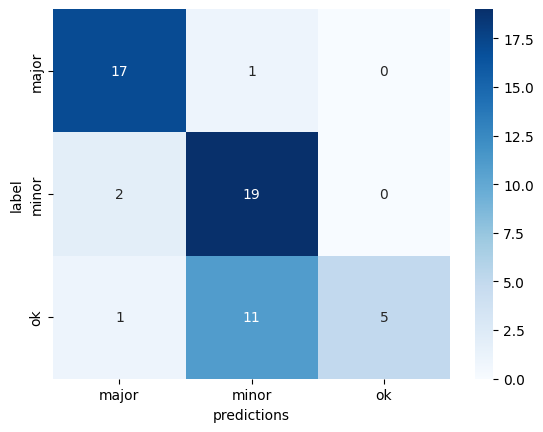

In [0]:
import matplotlib.pyplot as plt
import seaborn as sns

# create confusion matrix
confusion_matrix = pd.crosstab(results['label'], results['predictions'])

# plot confusion matrix
fig = plt.figure()
sns.heatmap(confusion_matrix, annot=True, cmap="Blues", fmt='d')
client.log_figure(run.info.run_id, fig, "confusion_matrix.png")


## Conclusion

We demonstrated how Databricks handle unstructured text and let you fine tune Deep Learning model, leveraging <b> Delta and MLFlow </b> to make process easy and reproducible. 

Our fine-tunbed model is now saved within Unity Catalog. Subsequent access and changes to it can be audited and managed centrally. 

Now that the model is available, let's see how we can use it for inferencing on new image data.

Open the [02.2-Batch-Scoring]($./02.2-Batch-Scoring) notebook to compute the incident severity on all our claims.